In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Step 1: Data Pre-processing & Augmentation**                                    

We will use ImageDataGenerator to handle resizing, normalization, and data augmentation. This ensures the models are robust and don't overfit.

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import os

# 1. SETUP PATHS
path_disease = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Leaf Disease Original Dataset'
path_growth = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Growth Stage Original Dataset'

# DEBUG: List the folders to be sure
print("Disease Subfolders:", os.listdir(path_disease))
print("Growth Subfolders:", os.listdir(path_growth))

import os

# This helper will find where the ACTUAL class folders are
def find_true_path(start_path):
    for root, dirs, files in os.walk(start_path):
        # If a folder contains more than one subfolder, it's likely our target
        if len(dirs) > 1:
            print(f"Found potential dataset root: {root}")
            print(f"Classes: {dirs}")
            return root
    return start_path

path_disease = find_true_path('/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Leaf Disease Original Dataset')
path_growth = find_true_path('/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Growth Stage Original Dataset')

# 2. UPDATED PRE-PROCESSING CONFIGURATION
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,      # Increased rotation
    width_shift_range=0.2,  # Added horizontal shift
    height_shift_range=0.2, # Added vertical shift
    shear_range=0.2,
    zoom_range=0.3,         # Increased zoom
    brightness_range=[0.8, 1.2], # Handle lighting variations
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# 3. CREATE DATA LOADERS
def get_generators(path):
    train = datagen.flow_from_directory(path, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='training')
    val = datagen.flow_from_directory(path, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='validation')
    return train, val

train_disease, val_disease = get_generators(path_disease)
train_growth, val_growth = get_generators(path_growth)

Disease Subfolders: ['Chili Leaf Disease Original Dataset']
Growth Subfolders: ['Chili Growth Stage Original Dataset']
Found potential dataset root: /content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Leaf Disease Original Dataset/Chili Leaf Disease Original Dataset
Classes: ['White spot', 'Healthy Leaf', 'Nutrition Deficiency', 'Bacterial Spot', 'Curl Virus', 'Cercospora Leaf Spot']
Found potential dataset root: /content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Chili Growth Stage Original Dataset/Chili Growth Stage Original Dataset
Classes: ['Rotten Chili', 'Red Chili', 'Green Chili', 'Flower', 'Dry chili']
Found 1487 images belonging to 6 classes.
Found 369 images belonging to 6 classes.
Found 1373 images belonging to 5 classes.
Found 341 images belonging to 5 classes.


**Step 2: Build the MobileNetV2 Model Function**                                     
Instead of writing the model twice, we create a function. We use Transfer Learning by freezing the base layers of MobileNetV2 (trained on 1.4 million images).


In [3]:
def build_optimized_mobilenet(num_classes):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Initially freeze the base
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x) # Increased units
    x = Dropout(0.5)(x)                  # Increased dropout to prevent overfitting
    x = Dense(128, activation='relu')(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    # Use a standard learning rate for the top layers
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model, base_model

# Initialize
model_disease, base_disease = build_optimized_mobilenet(train_disease.num_classes)
model_growth, base_growth = build_optimized_mobilenet(train_growth.num_classes)

**Step 3: Training the Models**                            

We will train both. I've added EarlyStopping so the training stops once the model reaches its peak accuracy.

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks to prevent overfitting and adjust learning rate
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
]

# --- Train Disease Model ---
print("\n--- Training Disease Model (Phase 1) ---")
model_disease.fit(train_disease, validation_data=val_disease, epochs=15, callbacks=callbacks)

# FINE-TUNING (Optional but highly recommended for accuracy)
model_disease.trainable = True
for layer in model_disease.layers[:-30]: # Freeze all but the last 30 layers
    layer.trainable = False

model_disease.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
print("\n--- Fine-Tuning Disease Model (Phase 2) ---")
model_disease.fit(train_disease, validation_data=val_disease, epochs=15, callbacks=callbacks)

# --- Train Growth Model ---
print("\n--- Training Growth Model (Phase 1) ---")
model_growth.fit(train_growth, validation_data=val_growth, epochs=15, callbacks=callbacks)


--- Training Disease Model (Phase 1) ---
Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.6281 - loss: 1.0141 - val_accuracy: 0.7940 - val_loss: 0.6843 - learning_rate: 0.0010
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 173s 4s/step - accuracy: 0.8453 - loss: 0.4453 - val_accuracy: 0.7724 - val_loss: 0.6918 - learning_rate: 0.0010
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.8843 - loss: 0.3445 - val_accuracy: 0.8564 - val_loss: 0.4881 - learning_rate: 0.0010
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.9025 - loss: 0.2804 - val_accuracy: 0.8672 - val_loss: 0.3847 - learning_rate: 0.0010
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 161s 3s/step - accuracy: 0.8931 - loss: 0.2985 - val_accuracy: 0.8401 - val_loss: 0.4803 - learning_rate: 0.0010
Epoch 6/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 165s 4s/step - accuracy: 0.9213 - loss: 0.2367 - val_accuracy: 0.8808 - val_loss: 0.4194 - learning_rate: 0.0010
Epoch 7/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step -

**Step 4: The Master Inference Script**                     

This is the "brain" of your project. It takes a single image and passes it through both models to give you a complete analysis.


In [5]:
import numpy as np
from tensorflow.keras.preprocessing import image

def analyze_chili_leaf(img_path):
    # 1. Pre-process the single image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # 2. Get Predictions
    p_disease = model_disease.predict(img_array)
    p_growth = model_growth.predict(img_array)

    # 3. Map to Class Names
    # Note: dict.items() gives (folder_name, index)
    disease_labels = {v: k for k, v in train_disease.class_indices.items()}
    growth_labels = {v: k for k, v in train_growth.class_indices.items()}

    res_disease = disease_labels[np.argmax(p_disease)]
    res_growth = growth_labels[np.argmax(p_growth)]

    # 4. Final Output
    print("-" * 30)
    print(f"FILE: {os.path.basename(img_path)}")
    print(f"HEALTH STATUS: {res_disease} ({np.max(p_disease)*100:.2f}%)")
    print(f"GROWTH STAGE:  {res_growth} ({np.max(p_growth)*100:.2f}%)")
    print("-" * 30)

# TEST IT
# Replace with a path to a real image from your drive
test_img = "/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/test_sample.jpg"
if os.path.exists(test_img):
    analyze_chili_leaf(test_img)

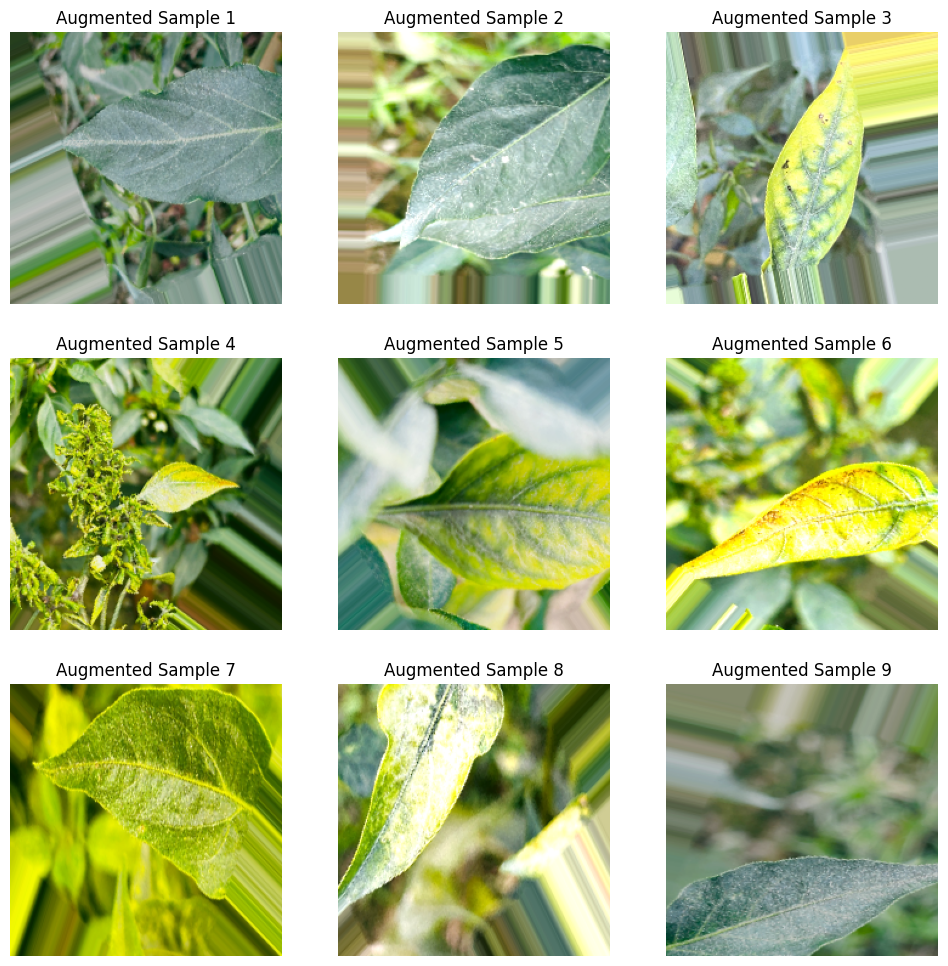

In [6]:
import matplotlib.pyplot as plt

# Grab one batch of 32 images from the Disease generator
x_batch, y_batch = next(train_disease)

plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i+1)
    # This shows how the 'datagen' has slightly rotated or zoomed the original images
    plt.imshow(x_batch[i])
    plt.title(f"Augmented Sample {i+1}")
    plt.axis('off')
plt.show()

In [8]:
# Create a dedicated folder for your models in Drive
model_save_path = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Saved_Models'
os.makedirs(model_save_path, exist_ok=True)

# Save the Disease Model
model_disease.save(f'{model_save_path}/chili_disease_mobilenet.h5')
print(f"Disease Model saved to: {model_save_path}/chili_disease_mobilenet.h5")

# Save the Growth Stage Model
model_growth.save(f'{model_save_path}/chili_growth_mobilenet.h5')
print(f"Growth Model saved to: {model_save_path}/chili_growth_mobilenet.h5")

Disease Model saved to: /content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Saved_Models/chili_disease_mobilenet.h5
Growth Model saved to: /content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Saved_Models/chili_growth_mobilenet.h5


In [10]:
from tensorflow.keras.models import load_model

# Load them back
model_disease = load_model('/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Saved_Models/chili_disease_mobilenet.h5')
model_growth = load_model('/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Saved_Models/chili_growth_mobilenet.h5')

print("Models loaded successfully! You can now use analyze_chili_leaf() immediately.")

Models loaded successfully! You can now use analyze_chili_leaf() immediately.


In [12]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Define the paths where you saved the models
model_path = '/content/drive/MyDrive/Colab Notebooks/Chilli Plant Dataset/Saved_Models'

# Load the models
model_disease = load_model(f'{model_path}/chili_disease_mobilenet.h5')
model_growth = load_model(f'{model_path}/chili_growth_mobilenet.h5')

print("Models loaded and ready for testing!")

Models loaded and ready for testing!


In [13]:
def predict_image(img_path):
    # Step A: Load and Resize image to 224x224
    img = image.load_img(img_path, target_size=(224, 224))

    # Step B: Convert to Numpy Array and Scale pixels (0 to 1)
    img_array = image.img_to_array(img) / 255.0

    # Step C: Add a 'Batch' dimension (MobileNet expects [1, 224, 224, 3])
    img_array = np.expand_dims(img_array, axis=0)

    # Step D: Run Inference
    disease_preds = model_disease.predict(img_array)
    growth_preds = model_growth.predict(img_array)

    # Step E: Get the index of the highest probability
    disease_idx = np.argmax(disease_preds)
    growth_idx = np.argmax(growth_preds)

    return disease_idx, growth_idx, np.max(disease_preds), np.max(growth_preds)

In [14]:
# 1. & 2. RE-SYNC LABELS (Run this after training/loading)
def get_clean_labels(generator):
    # This removes the parent folder path and gets just the subfolder names
    raw_indices = generator.class_indices
    return {v: k for k, v in raw_indices.items()}

# Update labels based on the NEW folder structure
disease_labels = {v: k for k, v in train_disease.class_indices.items()}
growth_labels = {v: k for k, v in train_growth.class_indices.items()}

def final_predict(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Inference
    d_preds = model_disease.predict(img_array, verbose=0)
    g_preds = model_growth.predict(img_array, verbose=0)

    d_idx = np.argmax(d_preds)
    g_idx = np.argmax(g_preds)

    print("=" * 45)
    print(f"FILE: {os.path.basename(img_path)}")
    print("-" * 45)
    print(f"DISEASE: {disease_labels[d_idx]} ({np.max(d_preds)*100:.2f}%)")
    print(f"GROWTH:  {growth_labels[g_idx]} ({np.max(g_preds)*100:.2f}%)")
    print("=" * 45)

# Test with your image
test_image_path = "/content/Screenshot 2026-05-08 232132.png"
final_predict(test_image_path)

FILE: Screenshot 2026-05-08 232132.png
---------------------------------------------
DISEASE: Cercospora Leaf Spot (82.99%)
GROWTH:  Green Chili (52.66%)
